# Experiment 1: Linear Structural Stress Test

This notebook summarizes the linear synthetic experiment for auditing model uniqueness.

The main question is:

> When a search method finds a large residual, is it a real uniqueness signal or just noise exploitation?

We use a three-stage protocol:

1. **Fitting**: fit a convex peer certificate $\hat w$ using baseline data.
2. **Search / Audit**: fix $\hat w$, then search for an action with maximum residual.
3. **Holdout**: re-evaluate the found action under new randomness or refitted certificate to test whether the residual persists.


## 1. Experiment setting

We use a local linear structural model:

$$

Y_j(x) = \phi(x)^\top \beta_j

$$

where each model $ j $ has its own coefficient vector $ \beta_j$.

The target is compared against the convex hull of peer models.

- `unique = 0`: the target is inside the peer convex hull, so any large residual should mainly come from noise or finite-sample effects.
- `unique = 1`: the target is outside the peer convex hull, so persistent residual indicates genuine uniqueness.


In [ ]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from IPython.display import display

plt.rcParams["figure.figsize"] = (7, 5)

# =========================
# Global configuration
# =========================
DIM = 20
K = 500
UNIQUE_VALUES = [0, 1]


TABLE_DIR = Path("/home/s243815/Adaptive-Model-Uniqueness/results/thesis_exp1")
FIGURE_DIR = Path("/home/s243815/Adaptive-Model-Uniqueness/results/thesis_exp1/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METHOD_CONFIGS = [
    {
        "method": "exp15",
        "label": "Random",
        "color": "gray",
        "suffix": "",
    },
    {
        "method": "exp18",
        "label": "CMA-ES",
        "color": "orange",
        "suffix": "",
    },
    {
        "method": "exp18",
        "label": "Robust CMA",
        "color": "green",
        "suffix": "_rep5_axis0_srob0p2_lam0p3",
    },
]

def config_key(method: str, suffix: str) -> str:
    return f"{method}|{suffix}"

label_map = {config_key(cfg["method"], cfg["suffix"]): cfg["label"] for cfg in METHOD_CONFIGS}
color_map = {config_key(cfg["method"], cfg["suffix"]): cfg["color"] for cfg in METHOD_CONFIGS}

label_map

{'exp15|': 'Random',
 'exp18|': 'CMA-ES',
 'exp18|_rep5_axis0_srob0p2_lam0p3': 'Robust CMA'}

## 2. Load search and holdout results

The notebook reads two types of files:

### Holdout files

These are produced by `exp20_holdout_eval.py`.

For each method, we read:

- `measurement`: denoising-style holdout, where the best action and certificate are fixed, and only output randomness/noise is re-sampled.
- `refit`: refit-style holdout, where a new baseline set is generated and the certificate is fitted again.

### Search curve files

These are produced by:

- `exp15_random_stress_test.py` for Random Search
- `exp18_cma_es_stress_test.py` for CMA-ES and Robust CMA

The final value of `best_residual` is used as the search-stage residual.


In [2]:
def build_holdout_file(eval_mode: str, cfg: dict, unique_value: int) -> Path:
    suffix_part = cfg["suffix"]
    return TABLE_DIR / (
        f"holdout_{cfg['method']}{suffix_part}_same_ecosystem_"
        f"{eval_mode}_dim{DIM}_K{K}_unique{unique_value}.csv"
    )

def build_stress_curve_candidates(method: str, suffix: str, seed: int, unique_value: int):
    suffix_part = suffix or ""

    return [
        TABLE_DIR / f"{method}_stress_curve{suffix_part}_dim{DIM}_K{K}_R3.0_seed{seed}_unique{unique_value}.csv",
        TABLE_DIR / f"{method}_stress_cma_curve{suffix_part}_dim{DIM}_K{K}_R3.0_seed{seed}_unique{unique_value}.csv",
    ]

def check_required_files(unique_value: int):
    missing = []

    for cfg in METHOD_CONFIGS:
        for eval_mode in ["measurement", "refit"]:
            path = build_holdout_file(eval_mode, cfg, unique_value)
            if not path.exists():
                missing.append(str(path))

    if missing:
        print(f"[unique={unique_value}] Missing holdout files:")
        for path in missing:
            print("  -", path)
    else:
        print(f"[unique={unique_value}] All holdout files found.")

for unique_value in UNIQUE_VALUES:
    check_required_files(unique_value)

[unique=0] All holdout files found.
[unique=1] All holdout files found.


In [3]:
def load_merged_df(unique_value: int) -> pd.DataFrame:
    measurement_files = [build_holdout_file("measurement", cfg, unique_value) for cfg in METHOD_CONFIGS]
    refit_files = [build_holdout_file("refit", cfg, unique_value) for cfg in METHOD_CONFIGS]

    df_m = pd.concat([pd.read_csv(f) for f in measurement_files], ignore_index=True)
    df_r = pd.concat([pd.read_csv(f) for f in refit_files], ignore_index=True)

    df = pd.merge(
        df_m,
        df_r,
        on=["seed", "method", "suffix", "mode", "dim", "K", "unique"],
        suffixes=("_m", "_r"),
    )

    df["suffix"] = df["suffix"].fillna("")

    search_values = []
    curve_paths = []

    for _, row in df.iterrows():
        suffix = row["suffix"] if pd.notna(row["suffix"]) else ""

        candidates = build_stress_curve_candidates(
            method=row["method"],
            suffix=suffix,
            seed=int(row["seed"]),
            unique_value=int(row["unique"]),
        )

        curve_path = None
        for candidate in candidates:
            if candidate.exists():
                curve_path = candidate
                break

        if curve_path is None:
            raise FileNotFoundError(
                "Could not find stress curve file. Tried:\n" 
                + "\n".join(str(c) for c in candidates)
            )

        curve_df = pd.read_csv(curve_path)
        search_values.append(float(curve_df["best_residual"].iloc[-1]))
        curve_paths.append(str(curve_path))

    df["search_best_residual"] = search_values
    df["curve_path"] = curve_paths
    df["plot_key"] = [config_key(m, s) for m, s in zip(df["method"], df["suffix"])]
    df["method_label"] = df["plot_key"].map(label_map)

    return df

dfs = {unique_value: load_merged_df(unique_value) for unique_value in UNIQUE_VALUES}

dfs[0].head()

,method,suffix,mode,eval_mode_m,dim,K,search_best_residual_m,gap_mean_m,seed,unique,...,tau_r,holdout_mean_r,holdout_std_r,exceed_count_r,exceed_rate_r,holdout_residuals_r,search_best_residual,curve_path,plot_key,method_label
0,exp15,,same_ecosystem,measurement,20,500,NaN,NaN,0,0,...,NaN,0.167057,0.129897,NaN,NaN,0.1540120924;0.2847524378;0.1451066233;0.53531...,0.750878,/Users/zhangxiangyun/Downloads/2/master/result...,exp15|,Random
1,exp15,,same_ecosystem,measurement,20,500,NaN,NaN,1,0,...,NaN,0.188593,0.150353,NaN,NaN,0.1306507583;0.2836437753;0.3549769535;0.04665...,0.626494,/Users/zhangxiangyun/Downloads/2/master/result...,exp15|,Random
2,exp15,,same_ecosystem,measurement,20,500,NaN,NaN,2,0,...,NaN,0.222240,0.153954,NaN,NaN,0.1059619448;0.1573470335;0.5847377114;0.13082...,0.723338,/Users/zhangxiangyun/Downloads/2/master/result...,exp15|,Random
3,exp15,,same_ecosystem,measurement,20,500,NaN,NaN,3,0,...,NaN,0.163202,0.108277,NaN,NaN,0.1666847570;0.1209976181;0.2804348707;0.08162...,0.624033,/Users/zhangxiangyun/Downloads/2/master/result...,exp15|,Random
4,exp15,,same_ecosystem,measurement,20,500,NaN,NaN,4,0,...,NaN,0.170883,0.134729,NaN,NaN,0.3447249940;0.0423381454;0.1528080188;0.01700...,0.606661,/Users/zhangxiangyun/Downloads/2/master/result...,exp15|,Random


## 3. Summary table

This table summarizes the mean and standard deviation across seeds.

- `search_best_residual`: the largest residual found during search.
- `holdout_mean_m`: denoised residual.
- `holdout_mean_r`: refit residual.


In [4]:
def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby(["method_label", "method", "suffix"], sort=False)
        .agg(
            search_mean=("search_best_residual", "mean"),
            search_std=("search_best_residual", "std"),
            denoised_mean=("holdout_mean_m", "mean"),
            denoised_std=("holdout_mean_m", "std"),
            refit_mean=("holdout_mean_r", "mean"),
            refit_std=("holdout_mean_r", "std"),
            n_seed=("seed", "nunique"),
        )
        .reset_index()
    )
    return summary

summary_unique0 = summarize_results(dfs[0])
summary_unique1 = summarize_results(dfs[1])

print("Unique = 0")
display(summary_unique0)

print("Unique = 1")
display(summary_unique1)

Unique = 0


,method_label,method,suffix,search_mean,search_std,denoised_mean,denoised_std,refit_mean,refit_std,n_seed
0,Random,exp15,,0.666281,0.065830,0.182935,0.036517,0.182395,0.024301,5
1,CMA-ES,exp18,,0.719985,0.106482,0.187478,0.018519,0.193027,0.019262,5
2,Robust CMA,exp18,_rep5_axis0_srob0p2_lam0p3,0.311760,0.037212,0.184196,0.020558,0.185525,0.009774,5


Unique = 1


,method_label,method,suffix,search_mean,search_std,denoised_mean,denoised_std,refit_mean,refit_std,n_seed
0,Random,exp15,,4.506692,0.617804,4.134929,1.293070,3.931475,1.215764,5
1,CMA-ES,exp18,,7.179824,0.196879,6.362639,0.397098,5.831027,0.420085,5
2,Robust CMA,exp18,_rep5_axis0_srob0p2_lam0p3,5.832977,0.555622,5.396071,0.455123,5.116853,1.274506,5


## 4. Search vs Refit bar plot

This is the main comparison.

For each method:

- Blue bar: residual found during search.
- Orange bar: residual after refit-style holdout.

Interpretation:

- If search residual is high but refit residual is low, the method may have exploited noise.
- If both search and refit residuals are high, the discovered action is more likely to reflect genuine uniqueness.


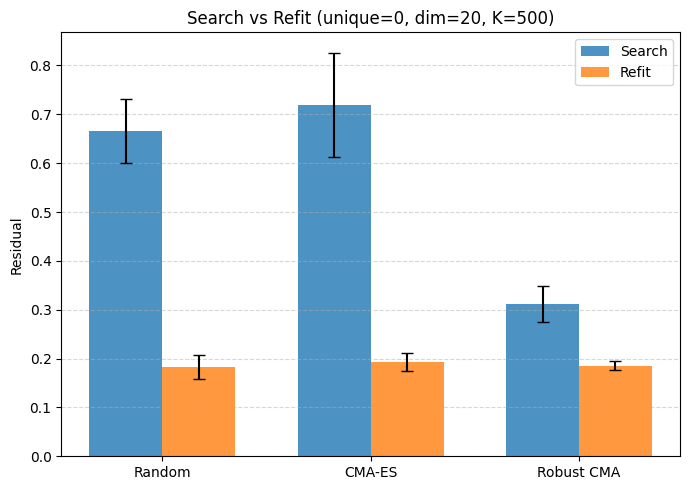

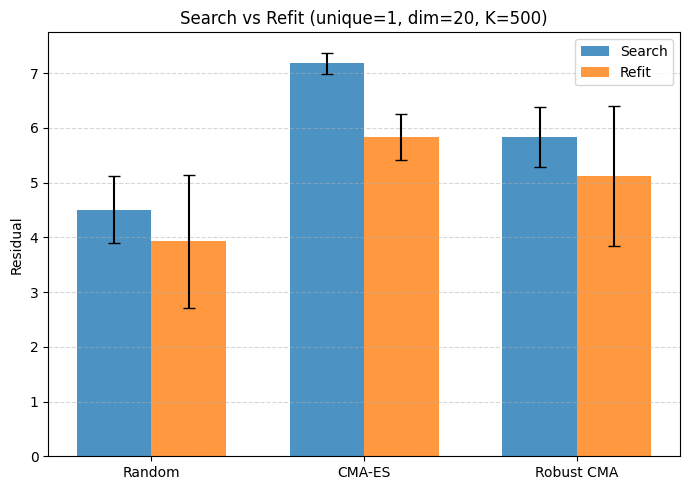

In [5]:
def plot_search_vs_refit_bar(df: pd.DataFrame, unique_value: int, save: bool = True):
    summary = summarize_results(df)

    labels = summary["method_label"].tolist()
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.bar(
        x - width / 2,
        summary["search_mean"],
        width,
        yerr=summary["search_std"],
        capsize=4,
        label="Search",
        alpha=0.8,
    )
    ax.bar(
        x + width / 2,
        summary["refit_mean"],
        width,
        yerr=summary["refit_std"],
        capsize=4,
        label="Refit",
        alpha=0.8,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Residual")
    ax.set_title(f"Search vs Refit (unique={unique_value}, dim={DIM}, K={K})")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    fig.tight_layout()

    if save:
        fig.savefig(FIGURE_DIR / f"bar_search_refit_unique{unique_value}_dim{DIM}_K{K}.png", dpi=200)

    display(fig)
    plt.close(fig)

    return fig, ax

for unique_value in UNIQUE_VALUES:
    plot_search_vs_refit_bar(dfs[unique_value], unique_value)

## 5. Search vs Denoised scatter plot

Each point corresponds to one seed.

The dashed line is \(y=x\).

- Points close to the diagonal mean that the search residual persists after denoising.
- Points far below the diagonal mean that the search residual is inflated by randomness.


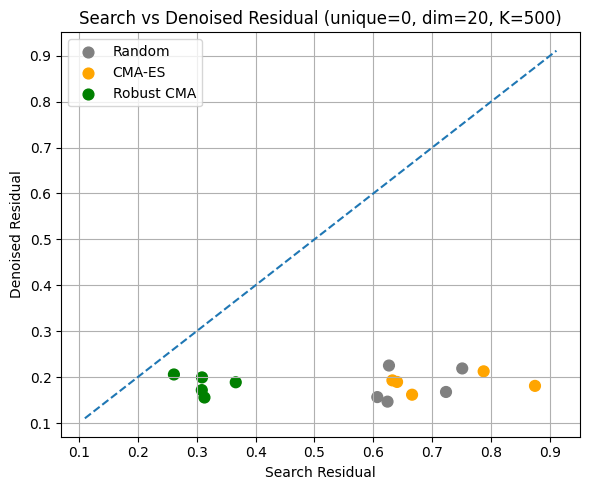

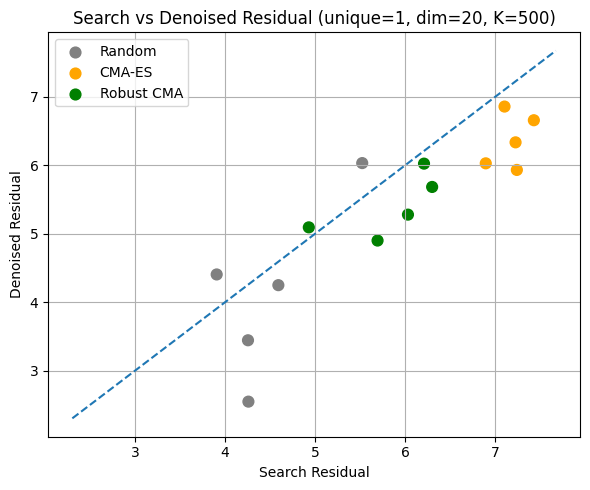

In [6]:
def plot_search_vs_metric_scatter(
    df: pd.DataFrame,
    unique_value: int,
    metric_col: str,
    metric_label: str,
    filename_prefix: str,
    save: bool = True,
):
    search = df["search_best_residual"]
    metric = df[metric_col]
    colors = [color_map.get(k, "black") for k in df["plot_key"]]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(search, metric, c=colors, s=60)

    for key, label in label_map.items():
        ax.scatter([], [], c=color_map[key], s=60, label=label)

    min_v = min(search.min(), metric.min())
    max_v = max(search.max(), metric.max())
    pad = 0.05 * (max_v - min_v) if max_v > min_v else 0.1
    ax.plot([min_v - pad, max_v + pad], [min_v - pad, max_v + pad], linestyle="--")

    ax.set_xlabel("Search Residual")
    ax.set_ylabel(metric_label)
    ax.set_title(f"Search vs {metric_label} (unique={unique_value}, dim={DIM}, K={K})")
    ax.legend()
    ax.grid(True)
    fig.tight_layout()

    if save:
        fig.savefig(FIGURE_DIR / f"{filename_prefix}_unique{unique_value}_dim{DIM}_K{K}.png", dpi=200)

    display(fig)
    plt.close(fig)

    return fig, ax

for unique_value in UNIQUE_VALUES:
    plot_search_vs_metric_scatter(
        dfs[unique_value],
        unique_value,
        metric_col="holdout_mean_m",
        metric_label="Denoised Residual",
        filename_prefix="search_vs_denoised",
    )

## 6. Search vs Refit scatter plot

This plot checks whether the discovered high-residual point still remains high after refitting the certificate on a new baseline sample.

This is a stricter generalization test than denoising.


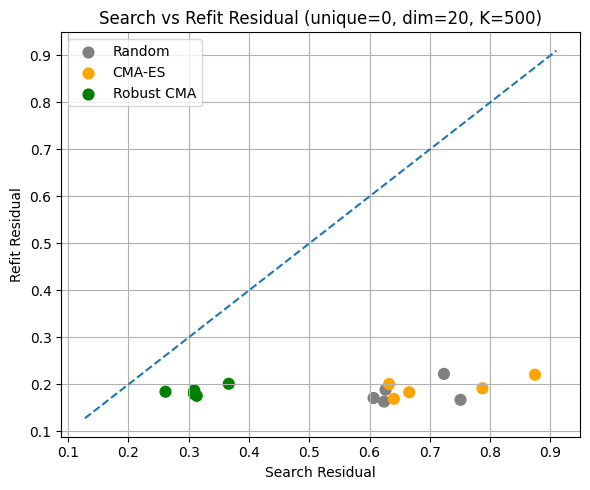

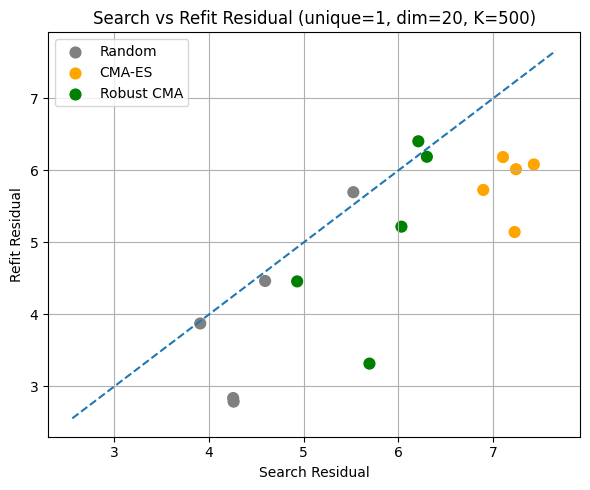

In [7]:
for unique_value in UNIQUE_VALUES:
    plot_search_vs_metric_scatter(
        dfs[unique_value],
        unique_value,
        metric_col="holdout_mean_r",
        metric_label="Refit Residual",
        filename_prefix="search_vs_refit",
    )

## 7. Search curves

The previous plots only use the final best residual.

Here we plot the full best-so-far residual curve across search budget.

This shows how quickly each method discovers high-residual actions.


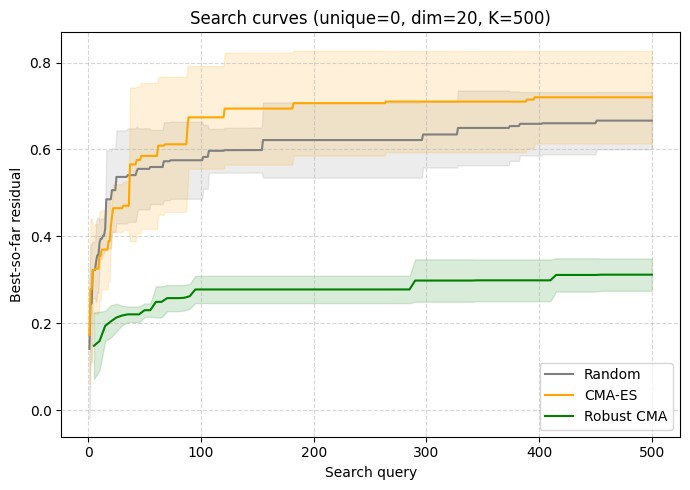

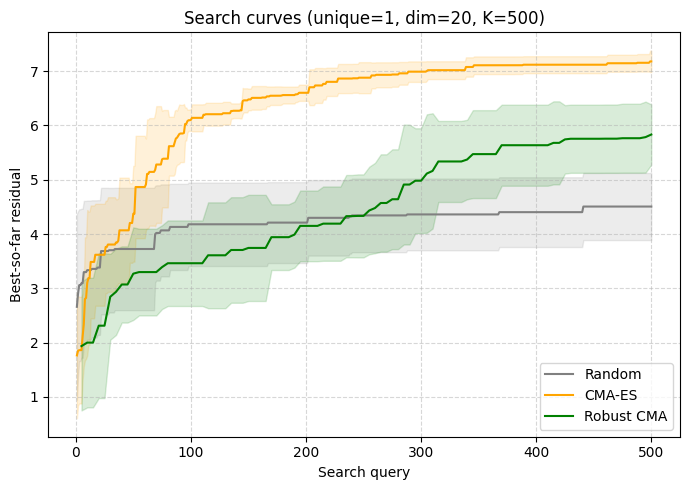

In [8]:
def load_curve_for_row(row: pd.Series) -> pd.DataFrame:
    path = Path(row["curve_path"])
    curve = pd.read_csv(path)
    curve["seed"] = row["seed"]
    curve["method_label"] = row["method_label"]
    curve["plot_key"] = row["plot_key"]
    return curve

def plot_search_curves(df: pd.DataFrame, unique_value: int, save: bool = True):
    curves = pd.concat([load_curve_for_row(row) for _, row in df.iterrows()], ignore_index=True)

    # Try to infer x-axis column
    if "query" in curves.columns:
        x_col = "query"
    elif "iter" in curves.columns:
        x_col = "iter"
    elif "step" in curves.columns:
        x_col = "step"
    else:
        curves = curves.copy()
        curves["query"] = curves.groupby(["method_label", "seed"]).cumcount() + 1
        x_col = "query"

    fig, ax = plt.subplots(figsize=(7, 5))

    for key, label in label_map.items():
        sub = curves[curves["plot_key"] == key]
        if sub.empty:
            continue

        grouped = (
            sub.groupby(x_col)
            .agg(mean_best=("best_residual", "mean"), std_best=("best_residual", "std"))
            .reset_index()
        )

        color = color_map[key]
        ax.plot(grouped[x_col], grouped["mean_best"], label=label, color=color)
        ax.fill_between(
            grouped[x_col],
            grouped["mean_best"] - grouped["std_best"],
            grouped["mean_best"] + grouped["std_best"],
            color=color,
            alpha=0.15,
        )

    ax.set_xlabel("Search query")
    ax.set_ylabel("Best-so-far residual")
    ax.set_title(f"Search curves (unique={unique_value}, dim={DIM}, K={K})")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()

    if save:
        fig.savefig(FIGURE_DIR / f"search_curves_unique{unique_value}_dim{DIM}_K{K}.png", dpi=200)

    display(fig)
    plt.close(fig)

    return fig, ax

for unique_value in UNIQUE_VALUES:
    plot_search_curves(dfs[unique_value], unique_value)

## 8. Interpretation

### Unique = 0

When the target is theoretically inside the peer convex hull, the true uniqueness should be small.

If search residual is high but holdout residual drops sharply, this suggests that the search method has discovered a noisy or unstable point rather than a real certificate failure.

### Unique = 1

When the target is outside the peer convex hull, the target contains behavior that cannot be expressed by a convex mixture of peers.

If high residual persists under denoising and refit holdout, this supports the interpretation that the discovered action corresponds to genuine uniqueness.

### Robust CMA

Robust CMA may not always produce the largest search residual, but it is designed to reduce overfitting to noisy residual spikes.

Therefore, the important question is not only:

> Which method finds the largest search residual?

but also:

> Which method finds residuals that persist under holdout?


## 9. Main takeaway

The linear experiment shows that search-stage residual alone is not enough.

A complete uniqueness audit should include:

1. **Fitting** a peer certificate.
2. **Searching** for high-residual actions.
3. **Validating** discovered actions with holdout evaluation.

This turns the experiment from a simple optimization benchmark into a certificate stress-testing protocol.
